In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

housing = fetch_california_housing(as_frame=True).frame
X = housing.iloc[:, :-1]
y = housing["MedHouseVal"]

# 1D CNN model

In [2]:
class CNN(nn.Module):
    def __init__(self, n_features, c1=8, c2=16, f=None):
        super().__init__()
        
        if f is None:
            f = [nn.ReLU, nn.ReLU, nn.ReLU]

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=c1, kernel_size=2)
        self.f1 = f[0]()

        self.conv2 = nn.Conv1d(in_channels=c1, out_channels=c2, kernel_size=2)
        self.f2 = f[1]()

        out = c2 * (n_features - 2)
        self.fc1 = nn.Linear(out, 32)
        self.f3 = f[2]()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        q = self.conv1(x)
        z0 = self.f1(q)
        
        v = self.conv2(z0)
        z1 = self.f2(v)

        z1 = torch.flatten(z1, start_dim=1)
        
        u = self.fc1(z1)
        z2 = self.f3(u)
        y = self.fc2(z2)
        
        return y

## Training and Validation 

In [3]:
def training(train_loader, X_test, y_test, model, criterion, optimizer):
    epochs = 200   
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_train, y_train in train_loader:
            optimizer.zero_grad()
            y_hat = model(X_train)
            loss = criterion(y_hat, y_train)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(train_loader)

        #if (epoch + 1) % 20 == 0:
        #    print(f"Epoch {epoch+1:3d} | Loss: {epoch_loss:.4f}")

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)
        val_loss = criterion(y_pred, y_test)

    print("Validation loss:", val_loss.item())
    #r2 = r2_score(y_test, y_pred)    
    return y_test, y_pred

## QoF 

In [4]:
import numpy as np
import torch

def QoF(y_true, y_pred, model):
        
    y_true = y_true.numpy().flatten()
    y_pred = y_pred.numpy().flatten()

    n = len(y_true)
    p = sum(p.numel() for p in model.parameters() if p.requires_grad)

    residuals = y_true - y_pred
    sse = np.sum(residuals**2)
    sst = np.sum((y_true - np.mean(y_true))**2)

    mse = sse / n
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))

    r2 = 1 - sse / sst
    
    aic = n * np.log(sse / n) + 2 * p
    bic = n * np.log(sse / n) + p * np.log(n)
        
    metrics = {"rSq": r2, 
                "sst": sst,
                "sse": sse,
                "mse": mse,
                "rmse": rmse,
                "mae": mae,
                "m": n,
                "aic": aic,
                "bic": bic
               }
    
    return pd.DataFrame([metrics]).T

## Plot actual vs. predicted

In [5]:
def plot(y_true, y_pred, name):
    
    y_true = y_true.numpy().flatten()
    y_pred = y_pred.numpy().flatten()
    
    idx = np.argsort(y_true)
    y_true_sorted = y_true[idx]
    y_pred_sorted = y_pred[idx]

    plt.figure(figsize=(8,5))
    plt.plot(y_pred_sorted, 'r.-', alpha=0.7, label="Predicted")
    plt.plot(y_true_sorted, 'k-', linewidth=2, label="True")
    
    title = name + ": yy black/actual vs. yp red/predicted" 
    plt.xlabel("Index")
    plt.ylabel("MPG")
    plt.title(title)
    plt.legend()

    plt.tight_layout()
    plt.show()

## In-Sample 

In [6]:
Xall = StandardScaler().fit_transform(X)
Xall = torch.tensor(Xall, dtype=torch.float32).unsqueeze(1)
yall = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

In [7]:
train_dataset = TensorDataset(Xall, yall)

train_loader = DataLoader(
    train_dataset,
    batch_size=Xall.shape[0],
    shuffle=True
)

model = CNN(n_features=8)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
y_true, y_pred = training(train_loader, Xall, yall, model, criterion, optimizer)

Validation loss: 0.32555124163627625


In [8]:
q1 = QoF(y_true, y_pred, model)

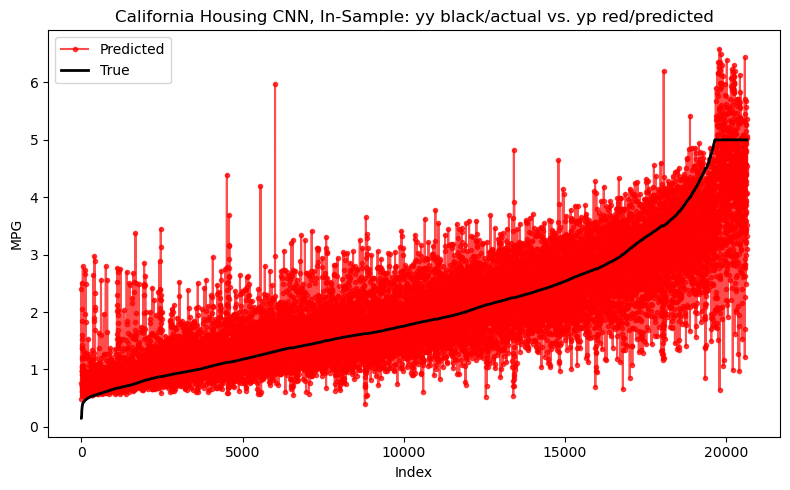

In [9]:
plot(y_true, y_pred, "California Housing CNN, In-Sample")

## Validation (80-20 train-test-split)

In [14]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [11]:
train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=X_train.shape[0],
    shuffle=True
)

model = CNN(n_features=8)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
y_true, y_pred = training(train_loader, X_test, y_test, model, criterion, optimizer)

Validation loss: 0.3683871328830719


In [12]:
q2 = QoF(y_true, y_pred, model)

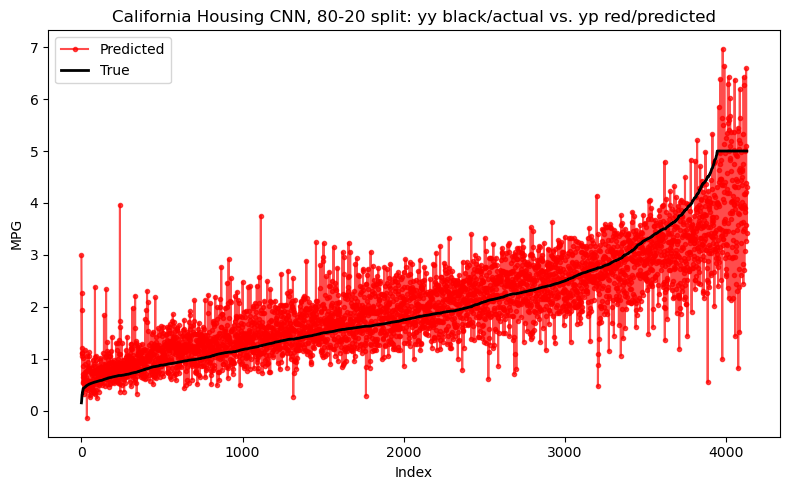

In [13]:
plot(y_true, y_pred, "California Housing CNN, 80-20 split")

### Save QoF  

In [15]:
q1.columns = ["In-Sample"]
q2.columns = ["80-20 Split"]
q = pd.concat([q1, q2], axis=1)
q.to_latex("latex/housing_whole_vs_split.tex", float_format="%.3f")

## Hyperparameter tuning for filter sizes (number of channels), activation functions,  learning rate, and mini-batch

In [16]:
train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=X_train.shape[0],
    shuffle=True
)

## Hyperparameter tuning: filter sizes (number of channels)

In [17]:
criterion = nn.MSELoss()
filters = [(4, 8), (8, 16), (16, 32), (8, 8), (16, 16)]

for c1, c2 in filters:
    print(f"Filter size: {c1, c2}")
    model = CNN(n_features=8, c1=c1, c2=c2)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    training(train_loader, X_test, y_test, model, criterion, optimizer)

Filter size: (4, 8)
Validation loss: 0.4004969000816345
Filter size: (8, 16)
Validation loss: 0.3497873544692993
Filter size: (16, 32)
Validation loss: 0.29893603920936584
Filter size: (8, 8)
Validation loss: 0.4108804166316986
Filter size: (16, 16)
Validation loss: 0.3026232421398163


## Fine tuning for activation functions

In [18]:
criterion = nn.MSELoss()

f = [[nn.Tanh, nn.Tanh, nn.ReLU],
     [nn.Tanh, nn.ReLU, nn.ReLU],
     [nn.ReLU, nn.ReLU, nn.ReLU]]

for af in f:
    print("Activation:", [a.__name__ for a in af])
    model = CNN(n_features=8, f=af)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    training(train_loader, X_test, y_test, model, criterion, optimizer)

Activation: ['Tanh', 'Tanh', 'ReLU']
Validation loss: 0.3535458743572235
Activation: ['Tanh', 'ReLU', 'ReLU']
Validation loss: 0.34896695613861084
Activation: ['ReLU', 'ReLU', 'ReLU']
Validation loss: 0.3282197117805481


## Fine tuning for learning rate

In [19]:
model = CNN(n_features=8)
criterion = nn.MSELoss()

for lr in (0.01, 0.02, 0.03, 0.04, 0.05):
    print(f"Learning rate: {lr}")
    optimizer = optim.Adam(model.parameters(), lr=lr)
    training(train_loader, X_test, y_test, model, criterion, optimizer)

Learning rate: 0.01
Validation loss: 0.3448789119720459
Learning rate: 0.02
Validation loss: 0.3063940703868866
Learning rate: 0.03
Validation loss: 0.30569449067115784
Learning rate: 0.04
Validation loss: 0.43159276247024536
Learning rate: 0.05
Validation loss: 0.3470149636268616


## Fine tuning for mini-batch 

In [20]:
model = CNN(n_features=8)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for i in (2, 4, 8, 16, 32):
    
    print(f"Batch size: {i}")
    
    train_dataset = TensorDataset(X_train, y_train)

    train_loader = DataLoader(
        train_dataset,
        batch_size=i,
        shuffle=True
    )
    
    training(train_loader, X_test, y_test, model, criterion, optimizer)

Batch size: 2
Validation loss: 0.3715565502643585
Batch size: 4
Validation loss: 0.49057888984680176
Batch size: 8
Validation loss: 0.39768844842910767
Batch size: 16
Validation loss: 0.34783273935317993
Batch size: 32
Validation loss: 0.33080780506134033


# Final model

In [21]:
model = CNN(n_features=8, c1=16, c2=32, f=[nn.ReLU, nn.ReLU, nn.ReLU])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.03)

## In-Sample 

Validation loss: 0.29876908659935


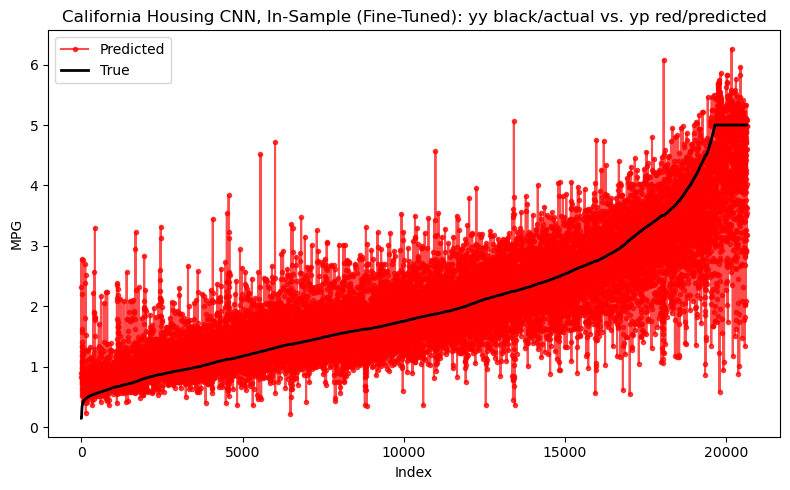

In [22]:
train_dataset = TensorDataset(Xall, yall)

train_loader = DataLoader(
    train_dataset,
    batch_size=Xall.shape[0],
    shuffle=True
)

y_true, y_pred = training(train_loader, Xall, yall, model, criterion, optimizer)
plot(y_true, y_pred, "California Housing CNN, In-Sample (Fine-Tuned)")
q1 = QoF(y_true, y_pred, model)

Validation loss: 0.3656201660633087


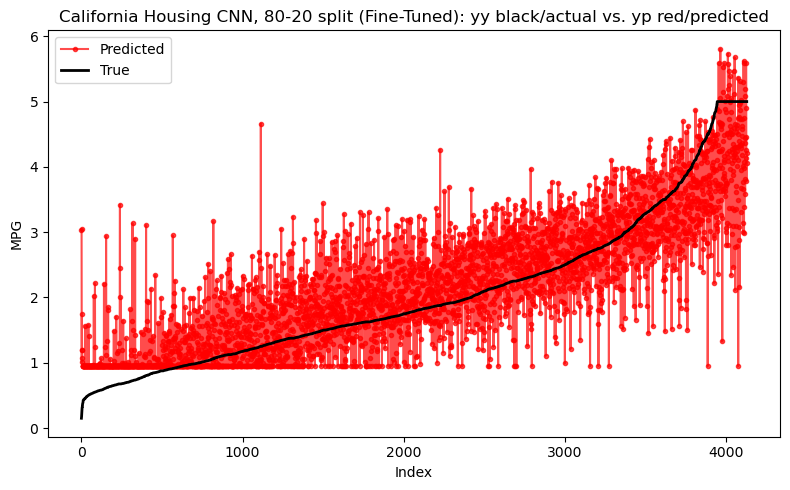

In [23]:
train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

y_true, y_pred = training(train_loader, X_test, y_test, model, criterion, optimizer)
plot(y_true, y_pred, "California Housing CNN, 80-20 split (Fine-Tuned)")
q2 = QoF(y_true, y_pred, model)

### Save QoF 

In [24]:
q1.columns = ["In-Sample"]
q2.columns = ["80-20 Split"]
q = pd.concat([q1, q2], axis=1)
q.to_latex("latex/housing_whole_vs_split_tuned.tex", float_format="%.3f")

In [ ]:
q